### Prior elicitation 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Current directory: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Contents: ['materials', '.DS_Store', 'requirements.txt', 'README.md', 'results', '.gitignore', 'requirements.bk.txt', '.git', 'results1', 'data', 'src']
/Users/sararedaelli/.cmdstan/cmdstan-2.37.0
cwd: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
first sys.path entries:
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload
   
   /Users/sararedaelli/Library/Python/3.13/lib/python/site-packages
project root guess: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
exists ./src ? True


In [ ]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

In [ ]:
model_names = [
    ("ab_baseline_simple_poi.stan", {}), 
    ("sr_invgamma", {"a":2,"b":1,"mu_alpha_0":0,"sigma_alpha_0":5}),
    ("sr_invgamma", {"a":2,"b":1,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_invgamma", {"a":4,"b":5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_tstudent", {"a":3,"b":0.5,"mu_alpha_0":0,"sigma_alpha_0":1})
    ("sr_tstudent", {"a":3,"b":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_tstudent", {"a":3,"b":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_normal", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":1})
    ("sr_normal", {"sigma_b":0.5,"mu_alpha_0":0,"sigma_alpha_0":10}),
    ("sr_normal", {"sigma_b":1,"mu_alpha_0":0,"sigma_alpha_0":10})
]

models = {}
for key in model_names:
    print(f"Compiling model: {key}")
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

In [17]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def sample_model(key, model_config, sample_config):
    glm_fit = model_config["model"].sample(
        data=model_config["data"], 
        **sample_config
    )
    return key, glm_fit


sample_config = {
    "chains": 4,  
    "parallel_chains": 4,
    "iter_warmup": 1200, 
    "iter_sampling": 5500,
    "show_console": True,
    "adapt_delta": 0.99,  # increase from 0.8
    "max_treedepth": 12, 
}


max_workers = 1
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(sample_model, k, v, sample_config): k 
        for k, v in models.items()
    }
    for future in as_completed(futures):
        key, fit = future.result()
        models[key]["fit"] = fit
        models[key]["az"] = az.from_cmdstanpy(fit)
        print(f"✓ Completed: {key}")

print("\n✓ All models fitted")

18:29:25 - cmdstanpy - INFO - Chain [1] start processing
18:29:25 - cmdstanpy - INFO - Chain [2] start processing
18:29:25 - cmdstanpy - INFO - Chain [3] start processing
18:29:25 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5500
Chain [1] num_warmup = 1200
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 12
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmppcgo__3g/h97ng24c.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 78542
C

18:37:08 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 66.578 seconds (Warm-up)
Chain [2] 396.178 seconds (Sampling)
Chain [2] 462.756 seconds (Total)
Chain [2] 
Chain [2] 
Chain [4] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [1] Iteration: 5000 / 6700 [ 74%]  (Sampling)
Chain [3] Iteration: 5200 / 6700 [ 77%]  (Sampling)
Chain [4] Iteration: 6500 / 6700 [ 97%]  (Sampling)
Chain [1] Iteration: 5100 / 6700 [ 76%]  (Sampling)
Chain [3] Iteration: 5300 / 6700 [ 79%]  (Sampling)
Chain [4] Iteration: 6600 / 6700 [ 98%]  (Sampling)
Chain [1] Iteration: 5200 / 6700 [ 77%]  (Sampling)


18:37:28 - cmdstanpy - INFO - Chain [4] done processing


...

Chain [3] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 87.369 seconds (Warm-up)
Chain [3] 302.257 seconds (Sampling)
Chain [3] 389.626 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 6200 / 6700 [ 92%]  (Sampling)
Chain [1] Iteration: 5700 / 6700 [ 85%]  (Sampling)
Chain [4] Iteration: 6300 / 6700 [ 94%]  (Sampling)
Chain [1] Iteration: 5800 / 6700 [ 86%]  (Sampling)
Chain [4] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [1] Iteration: 5900 / 6700 [ 88%]  (Sampling)
Chain [4] Iteration: 6500 / 6700 [ 97%]  (Sampling)
Chain [1] Iteration: 6000 / 6700 [ 89%]  (Sampling)
Chain [4] Iteration: 6600 / 6700 [ 98%]  (Sampling)
Chain [1] Iteration: 6100 / 6700 [ 91%]  (Sampling)


18:55:57 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 109.952 seconds (Warm-up)
Chain [4] 294.692 seconds (Sampling)
Chain [4] 404.644 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 6200 / 6700 [ 92%]  (Sampling)
Chain [1] Iteration: 6300 / 6700 [ 94%]  (Sampling)
Chain [1] Iteration: 6400 / 6700 [ 95%]  (Sampling)
Chain [1] Iteration: 6500 / 6700 [ 97%]  (Sampling)
Chain [1] Iteration: 6600 / 6700 [ 98%]  (Sampling)


18:56:08 - cmdstanpy - INFO - Chain [1] done processing
18:56:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'prior_tstudent_31.stan', line 39, column 8 to column 45)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'prior_tstudent_31.stan', line 64, column 12 to column 53)


Chain [1] Iteration: 6700 / 6700 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 133.594 seconds (Warm-up)
Chain [1] 282.61 seconds (Sampling)
Chain [1] 416.204 seconds (Total)
Chain [1] 
Chain [1] 
✓ Completed: prior_tstudent_31.stan

✓ All models fitted


In [18]:
for key in models:
    poi_glm_data = models[key]["az"]
    print("divergence of ",key,np.sum(poi_glm_data.sample_stats.diverging))

divergence of  ab_baseline_simple_poi.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  prior_invgamma_54.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence of  prior_tstudent_31.stan <xarray.DataArray 'diverging' ()> Size: 8B
array(0)


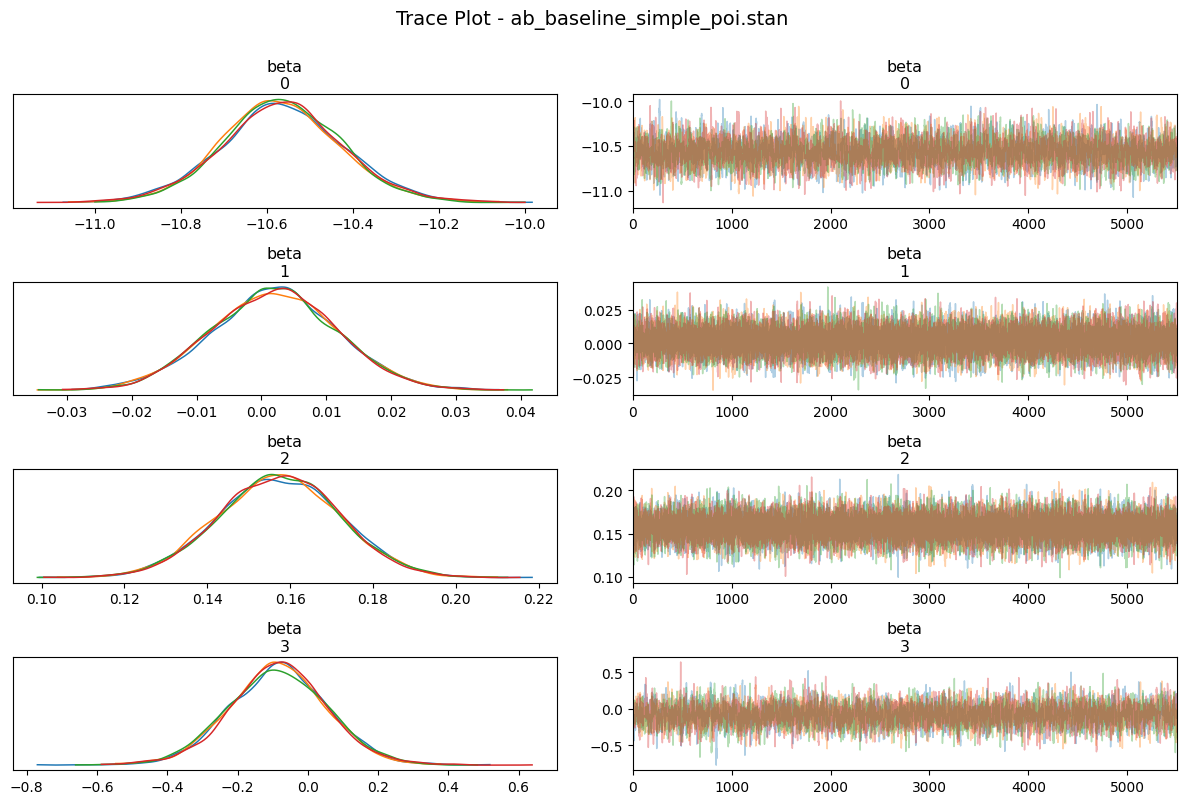

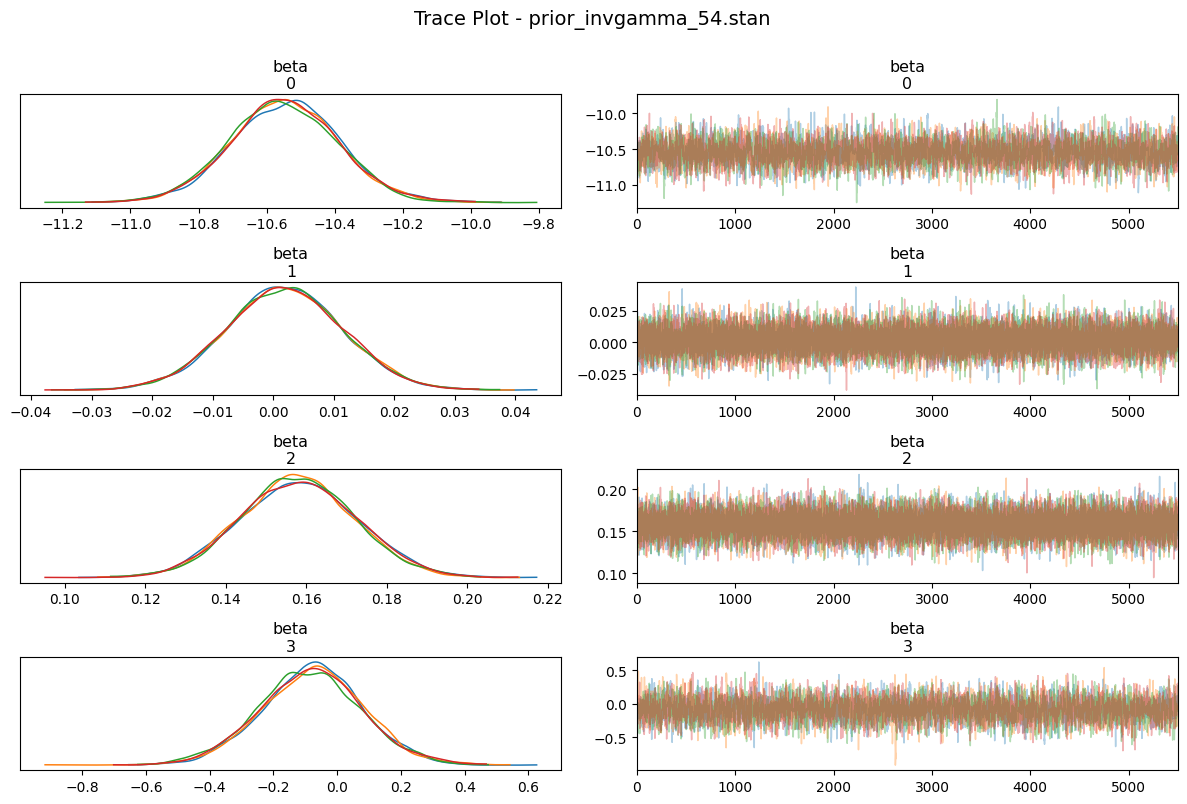

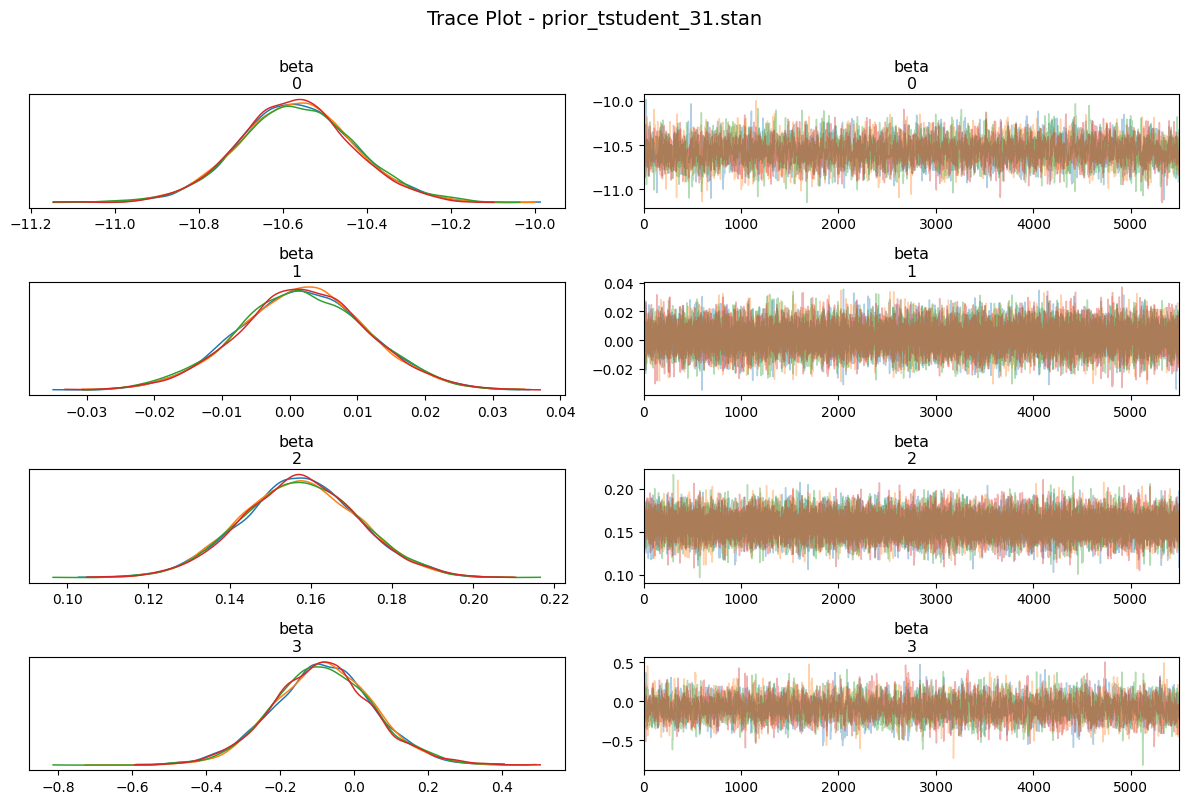

In [19]:
for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_trace(poi_glm_data, var_names=["beta"], compact=False)
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

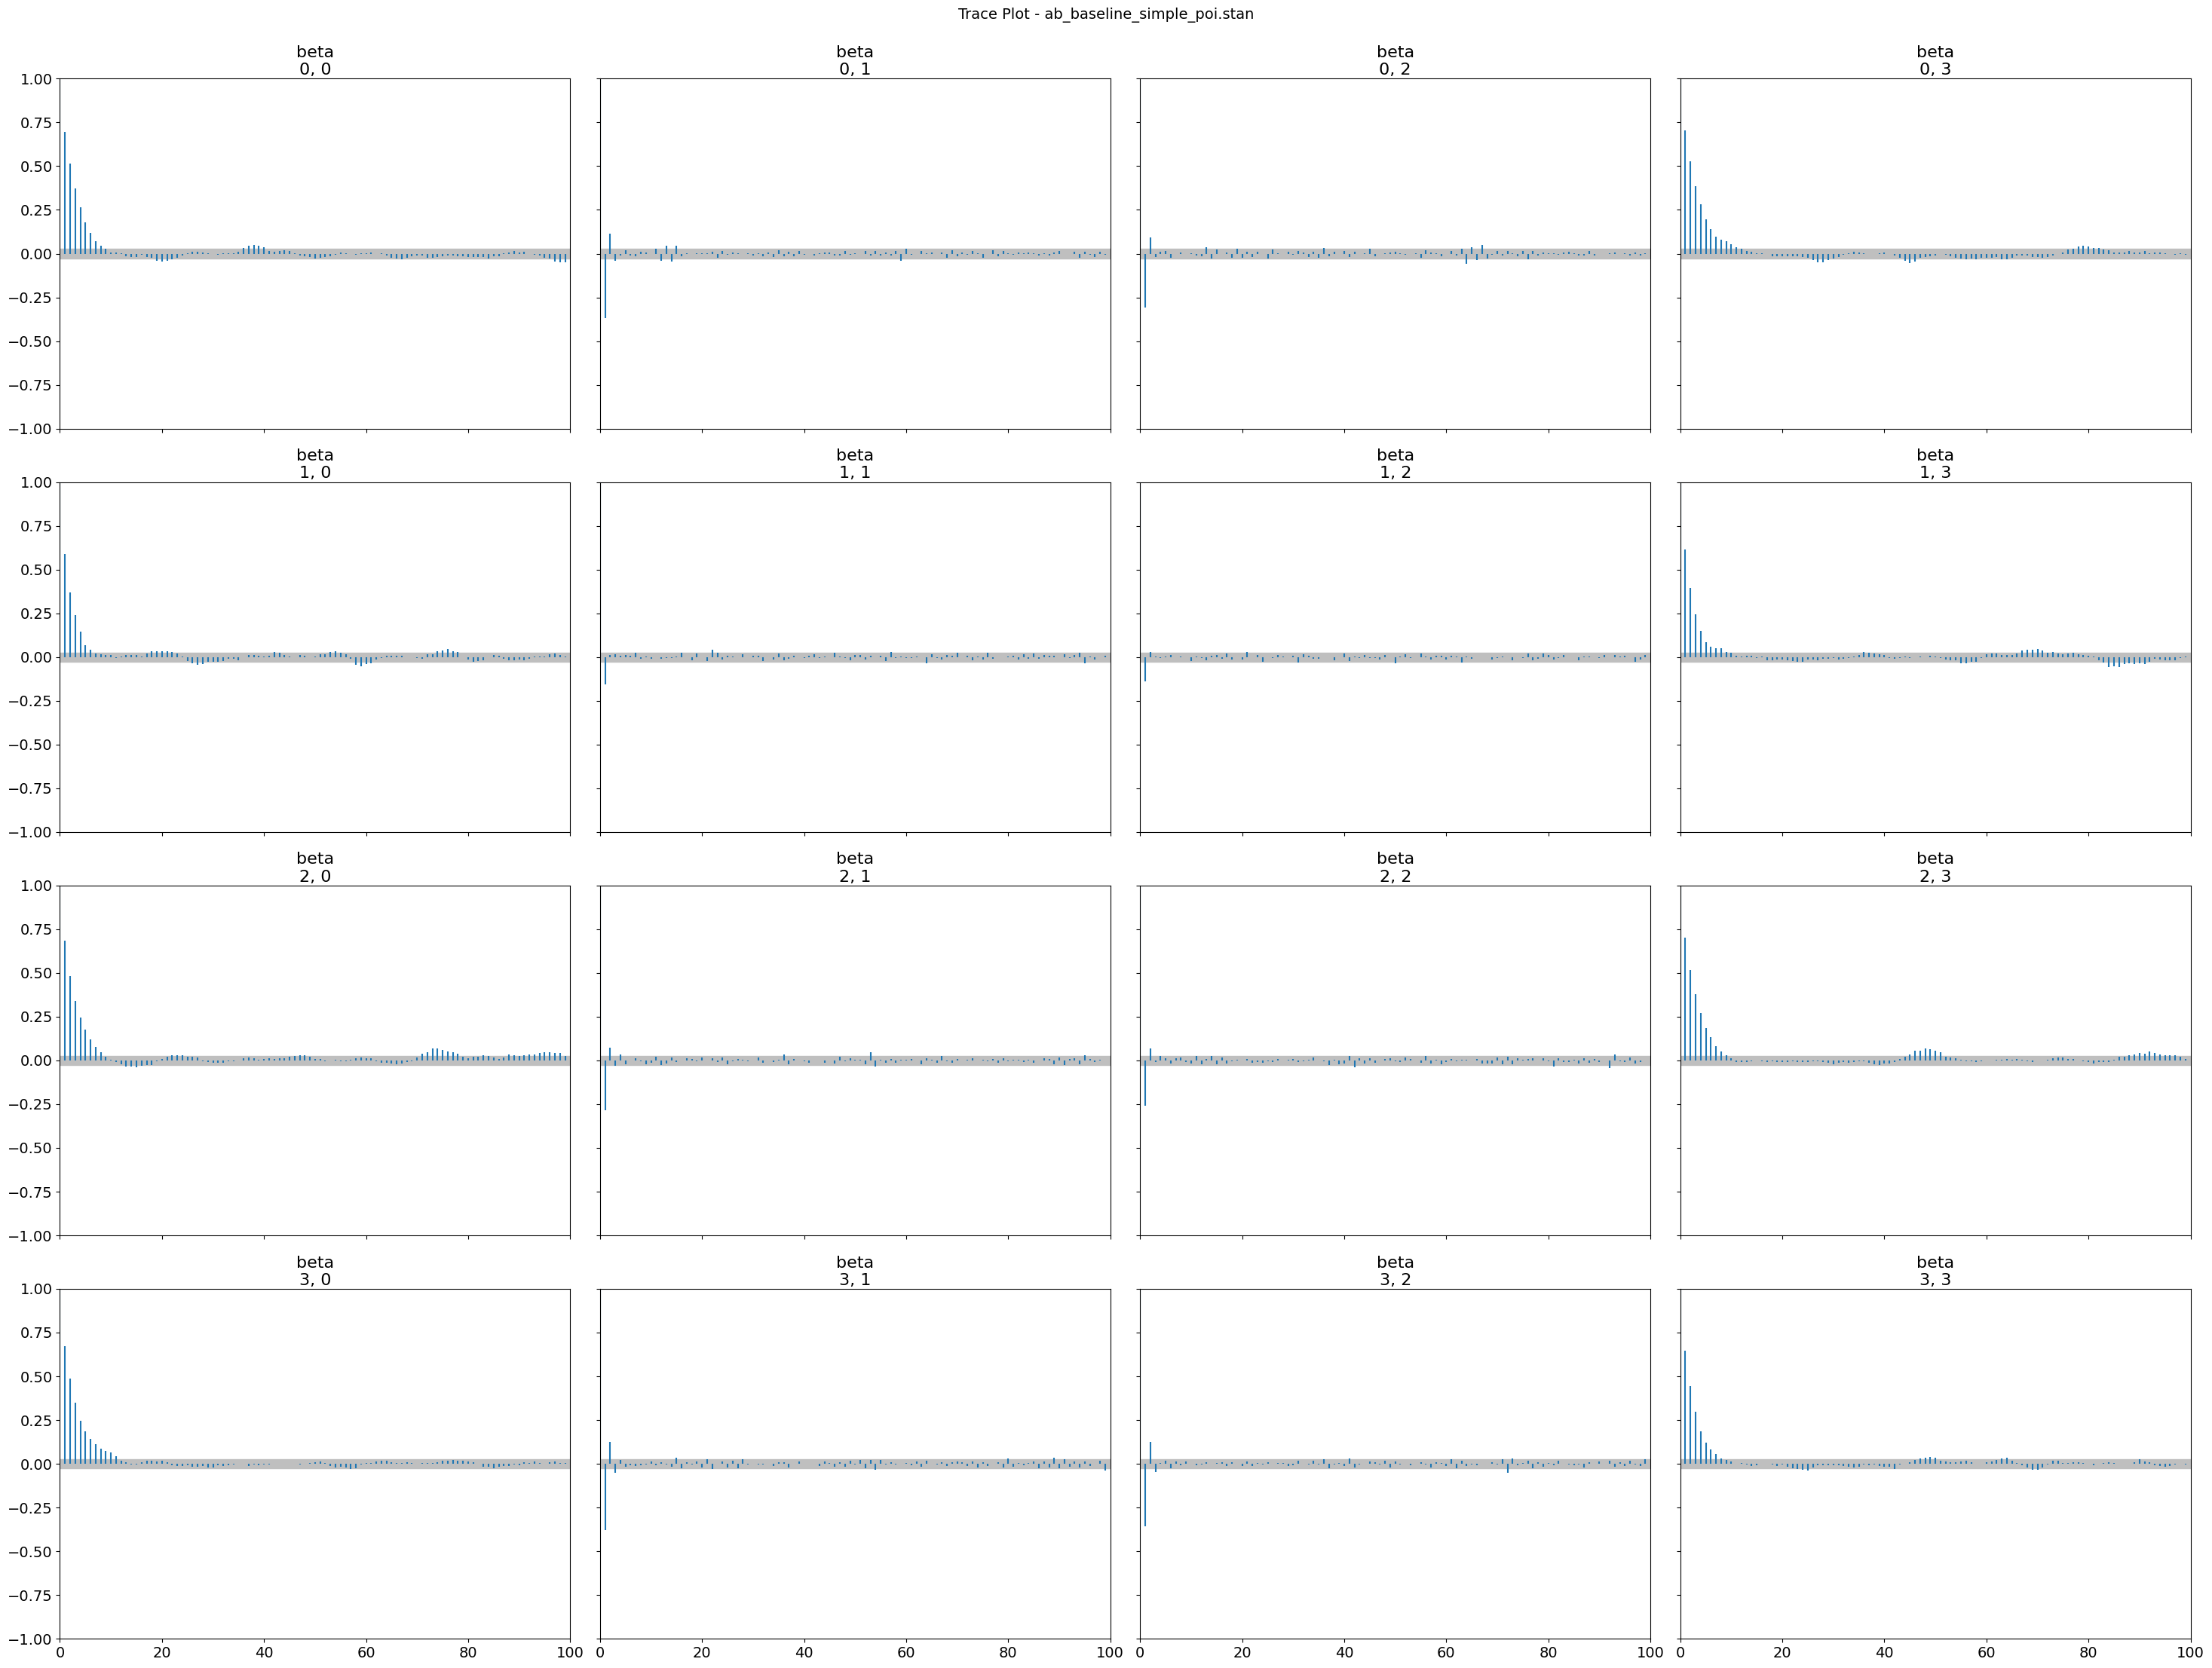

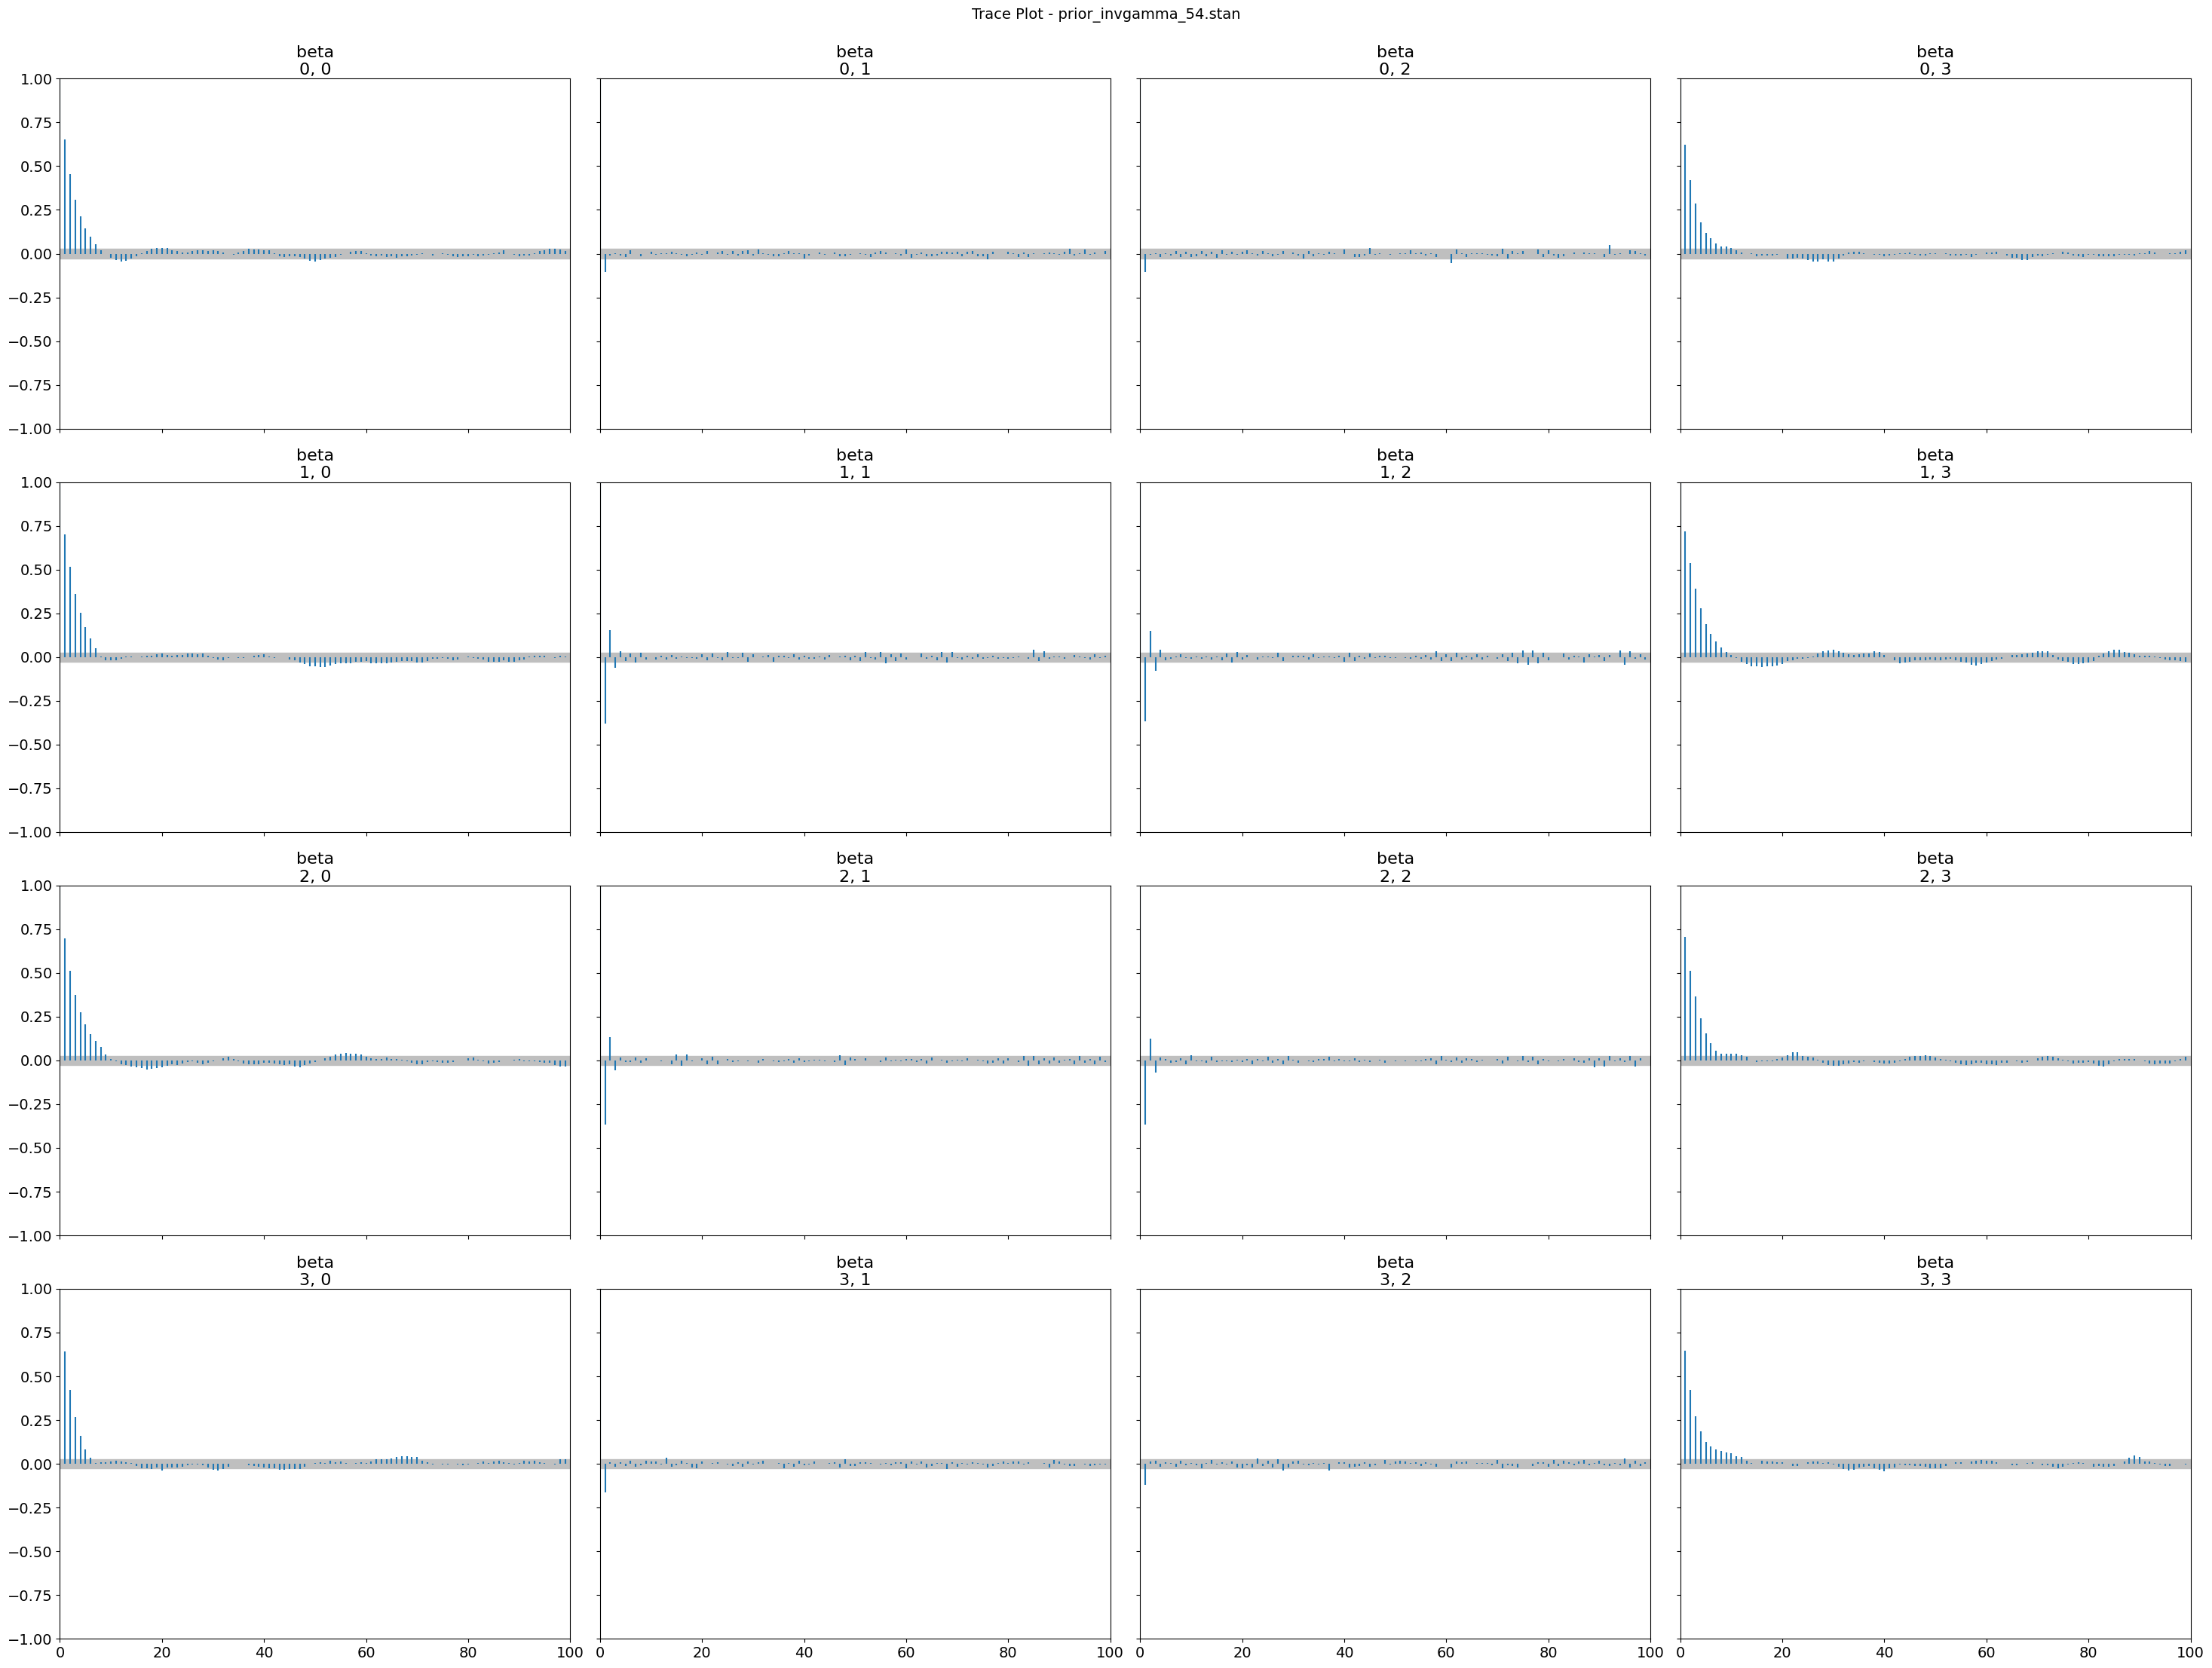

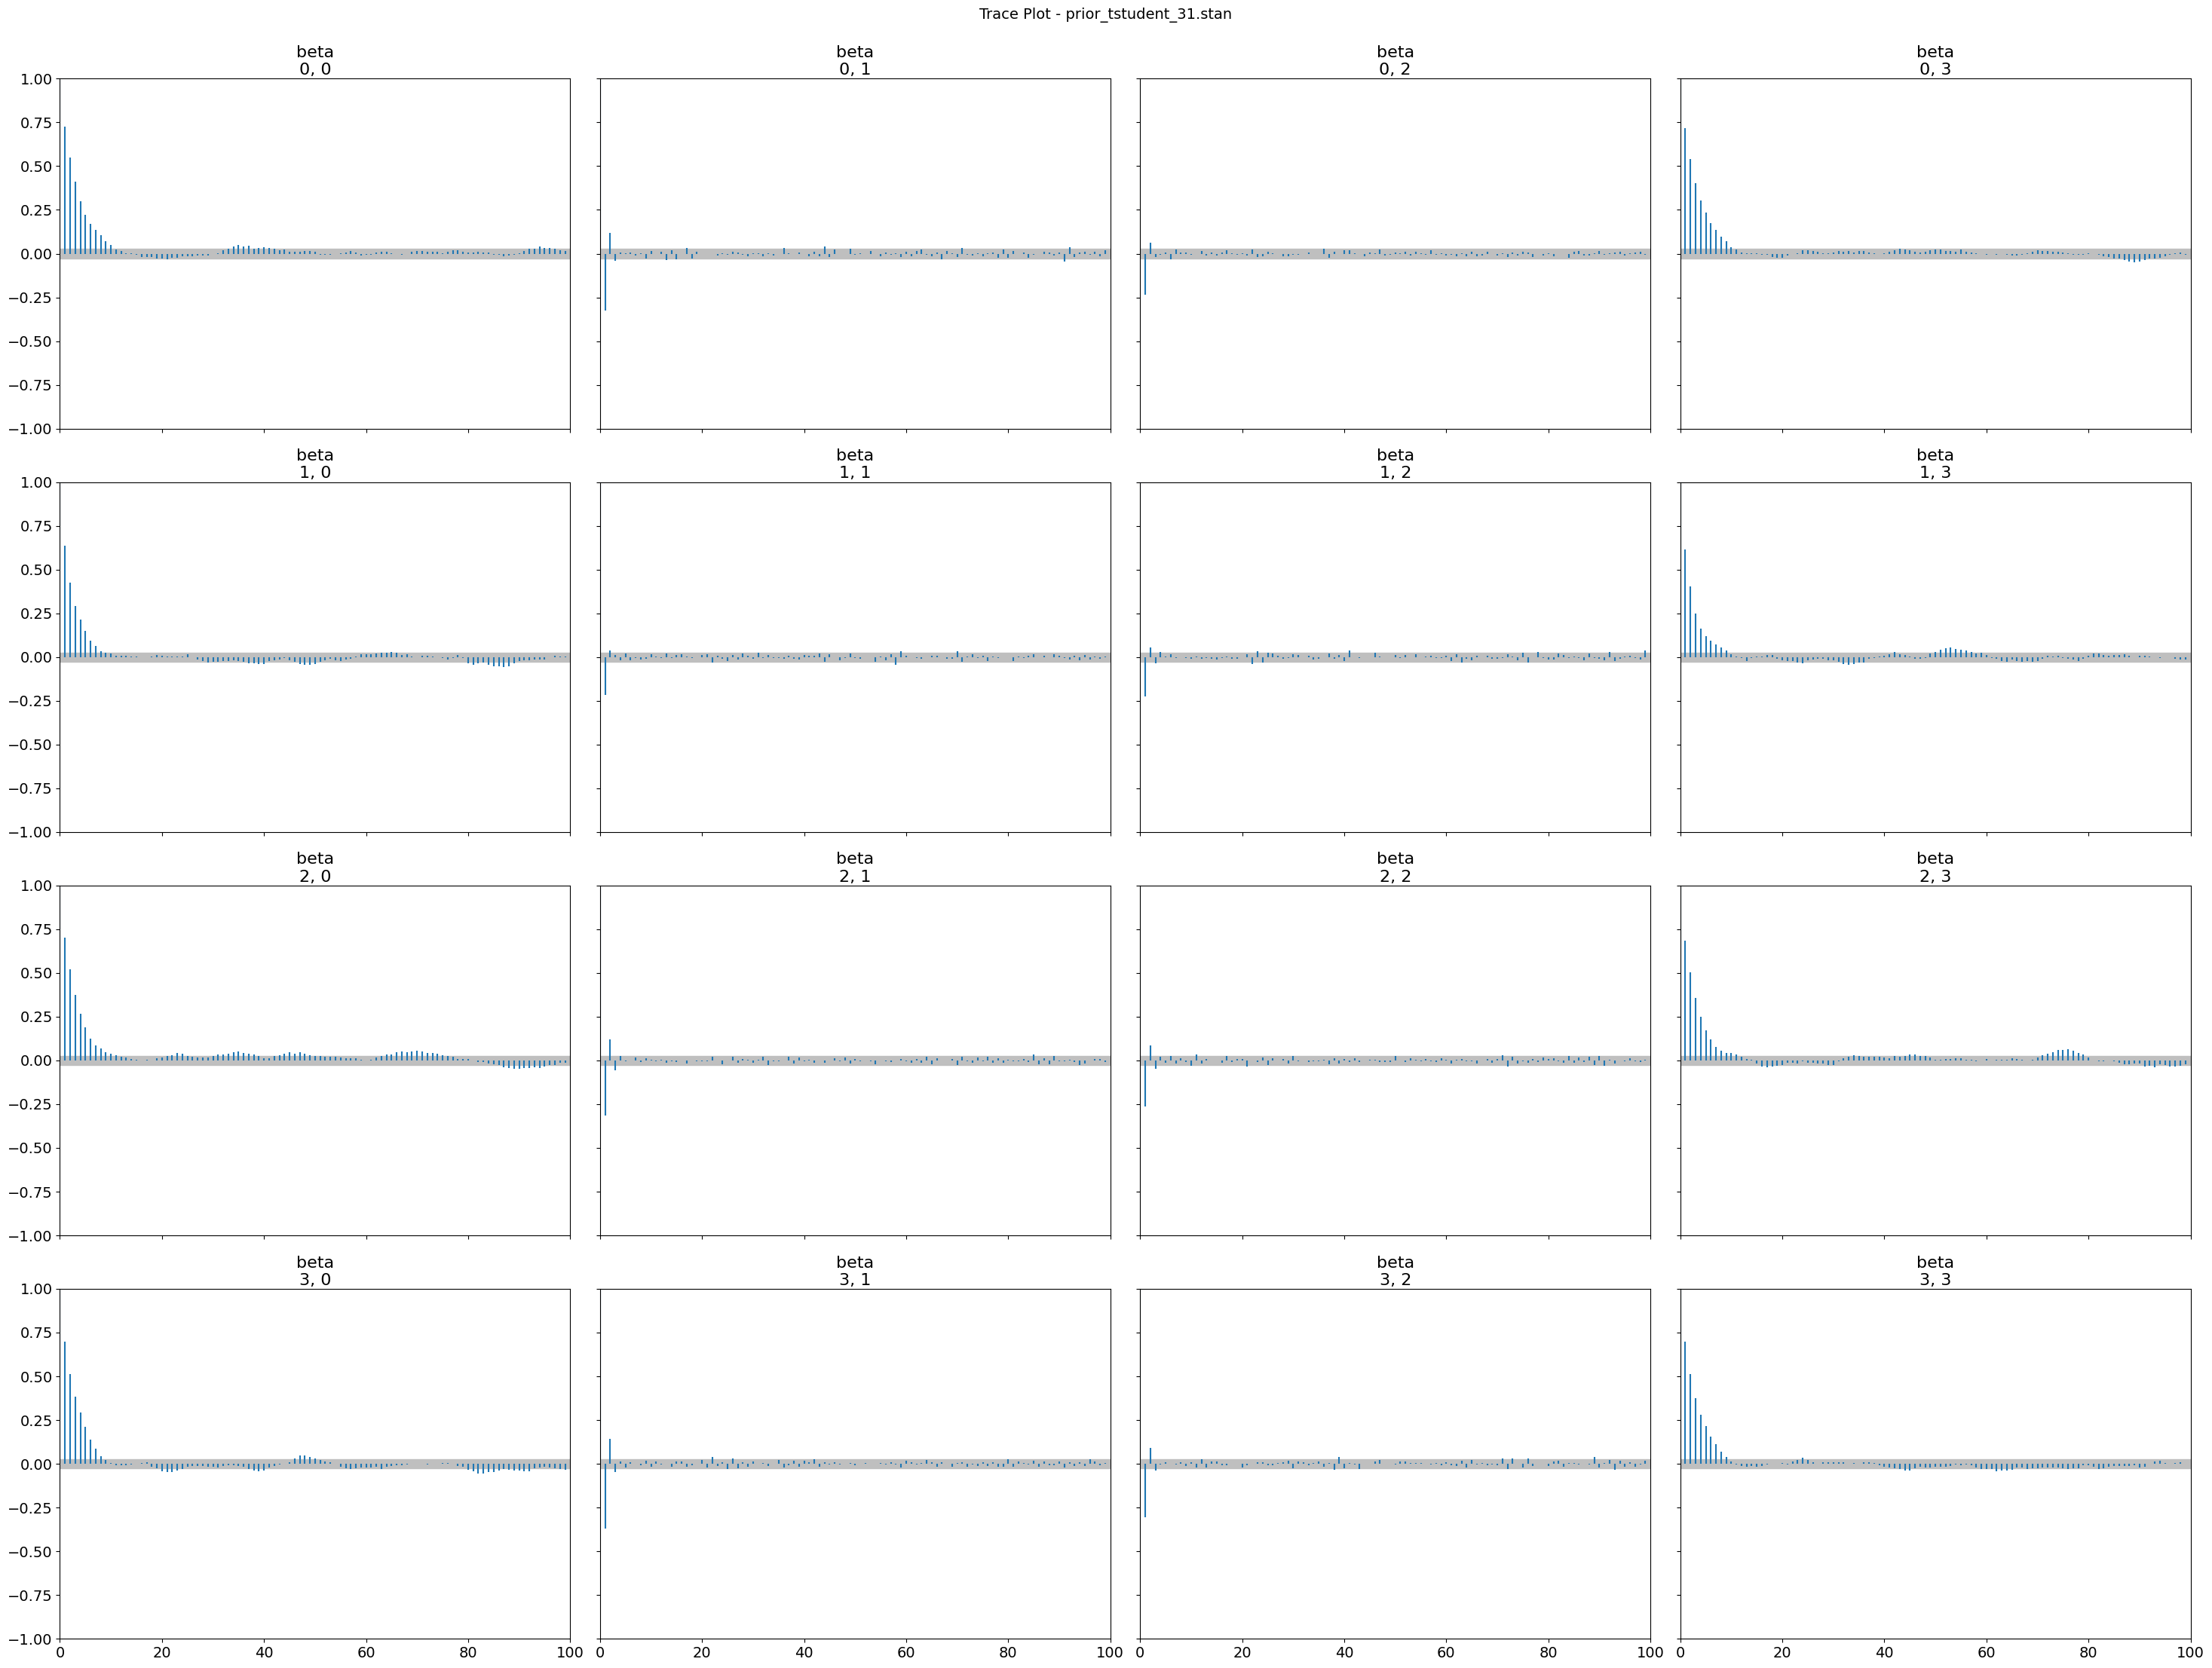

In [20]:

for key in models:
    poi_glm_data = models[key]["az"]
    az.plot_autocorr(poi_glm_data, var_names=["beta"])
    plt.suptitle(f"Trace Plot - {key}", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show() 

In [21]:
model_names = list(models.keys())
models[model_names[0]]["fit"].summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68878.900000,0.050640,4.516690,4.494500,68870.900000,68879.200000,68885.600000,8004.25,13679.10,4.88896,1.000180
beta[1],-10.564300,0.002179,0.140970,0.135332,-10.795000,-10.566600,-10.329800,4187.34,6507.97,2.55761,1.000670
beta[2],0.001957,0.000048,0.009706,0.009642,-0.014037,0.002024,0.017975,40730.60,15968.50,24.87810,0.999956
beta[3],0.157407,0.000078,0.014656,0.014616,0.133279,0.157433,0.181532,34977.20,13997.90,21.36390,1.000020
beta[4],-0.084316,0.002196,0.141234,0.136675,-0.315324,-0.083931,0.145152,4136.38,6372.09,2.52649,1.000760
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.544200,0.001001,0.139028,0.096933,-2.829010,-2.497350,-2.421780,21742.10,18134.80,13.28000,0.999923
log_lik[375],-3.200120,0.002645,0.398028,0.388297,-3.929880,-3.155170,-2.631000,22985.50,18047.20,14.03940,0.999910
log_lik[376],-2.180700,0.000978,0.148173,0.148244,-2.431650,-2.177690,-1.942000,22985.50,18047.20,14.03940,0.999906
log_lik[377],-1.403360,0.000531,0.080293,0.080190,-1.543080,-1.399430,-1.278280,22985.50,18047.20,14.03950,0.999907


In [22]:
glm_fit = models[model_names[1]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68866.600000,0.051569,4.559570,4.527860,68858.600000,68866.900000,68873.500000,7831.63,11856.10,4.99774,1.00012
beta[1],-10.547500,0.002439,0.160378,0.157260,-10.809700,-10.547800,-10.285000,4337.56,6566.76,2.76801,1.00070
beta[2],0.001878,0.000050,0.009631,0.009526,-0.013892,0.001872,0.017675,37947.40,15545.00,24.21610,1.00016
beta[3],0.157966,0.000076,0.014404,0.014317,0.134383,0.157914,0.181723,35614.20,16315.80,22.72720,1.00041
beta[4],-0.081445,0.002538,0.161789,0.157388,-0.350443,-0.078827,0.181965,4070.24,6627.49,2.59742,1.00119
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.545420,0.001037,0.142181,0.097121,-2.836570,-2.496940,-2.421750,21754.70,17434.80,13.88280,1.00001
log_lik[375],-3.201070,0.002718,0.404155,0.392209,-3.944390,-3.152570,-2.626300,22292.60,17109.50,14.22600,1.00018
log_lik[376],-2.180690,0.001006,0.150184,0.150151,-2.435890,-2.176710,-1.939320,22292.60,17109.50,14.22600,1.00023
log_lik[377],-1.403420,0.000545,0.081423,0.081035,-1.545580,-1.398900,-1.276980,22292.60,17109.50,14.22600,1.00022


In [23]:
glm_fit = models[model_names[2]]["fit"]
glm_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68869.900000,0.054130,4.522220,4.532310,68862.000000,68870.300000,68876.800000,7096.24,12120.40,6.07305,1.00065
beta[1],-10.568800,0.002254,0.138533,0.133822,-10.793300,-10.570100,-10.337800,3795.61,6213.46,3.24833,1.00108
beta[2],0.001925,0.000047,0.009578,0.009433,-0.013896,0.001866,0.017862,41315.90,15813.50,35.35860,1.00028
beta[3],0.157301,0.000075,0.014481,0.014365,0.133424,0.157286,0.181249,37424.70,15135.10,32.02850,1.00046
beta[4],-0.084588,0.002210,0.137300,0.133267,-0.306892,-0.085079,0.144370,3869.04,5830.05,3.31117,1.00124
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.543250,0.001034,0.138847,0.095752,-2.819160,-2.496040,-2.421770,21069.90,17411.20,18.03180,1.00048
log_lik[375],-3.196760,0.002674,0.397674,0.389221,-3.910610,-3.150310,-2.631250,22794.40,17518.50,19.50770,1.00048
log_lik[376],-2.179400,0.000982,0.148280,0.148522,-2.426000,-2.175860,-1.942140,22794.40,17518.50,19.50770,1.00047
log_lik[377],-1.402670,0.000533,0.080306,0.080282,-1.539760,-1.398430,-1.278350,22794.40,17518.50,19.50770,1.00048


array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

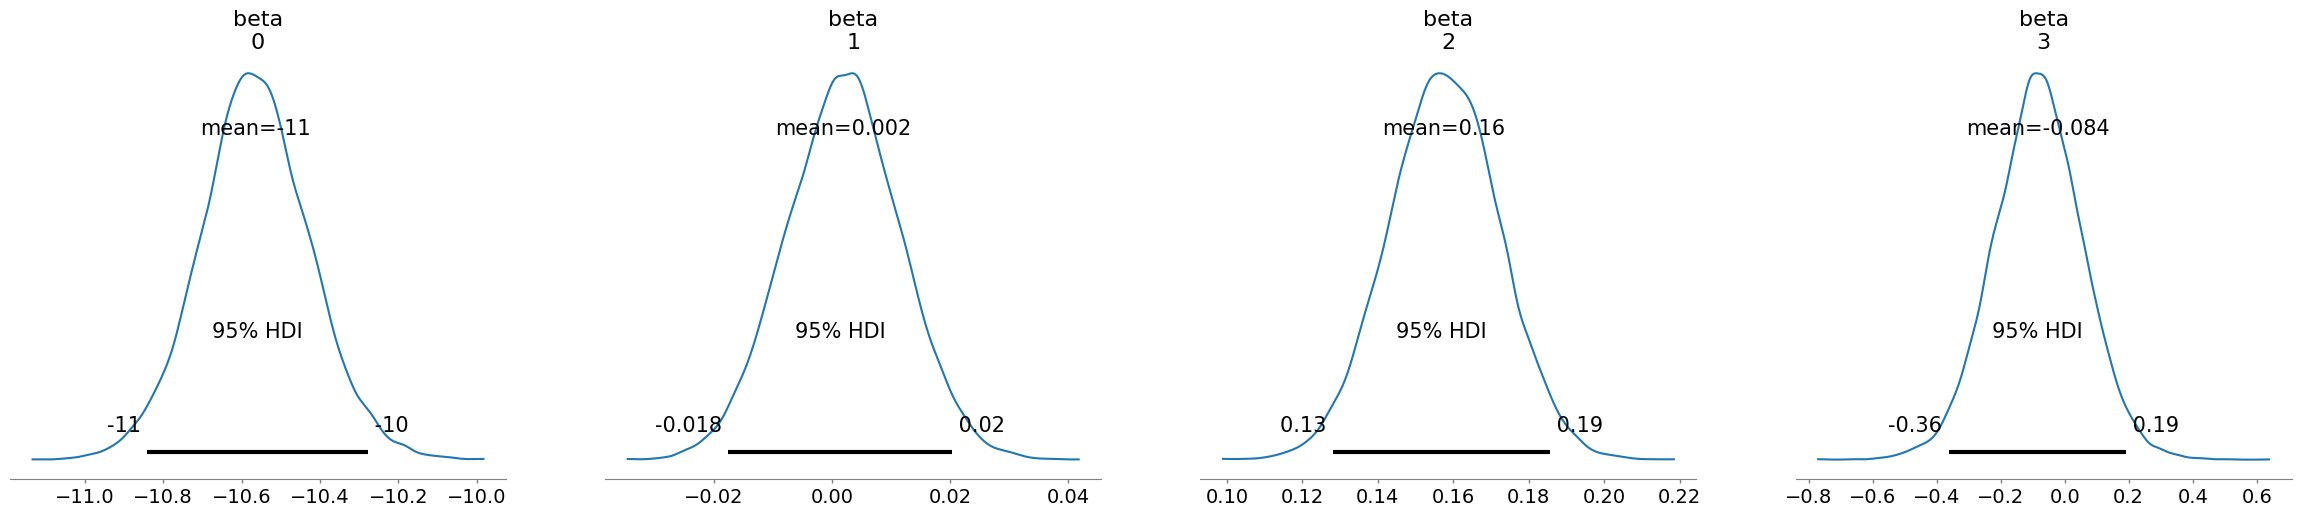

In [24]:
az.plot_posterior(models[model_names[0]]["fit"], var_names=["beta"], hdi_prob=0.95)

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

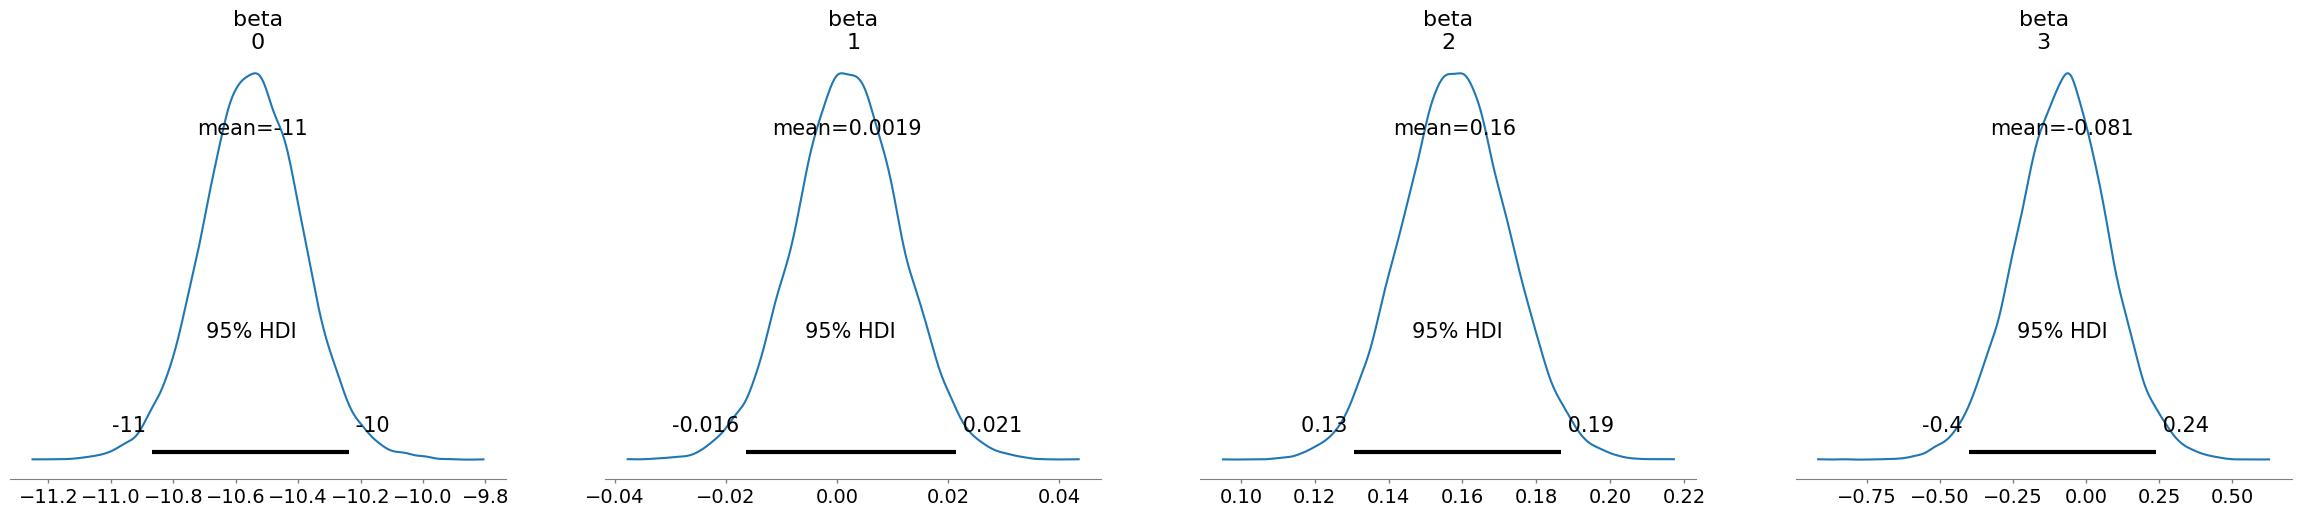

In [25]:
az.plot_posterior(models[model_names[1]]["fit"], var_names=["beta"], hdi_prob=0.95)

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

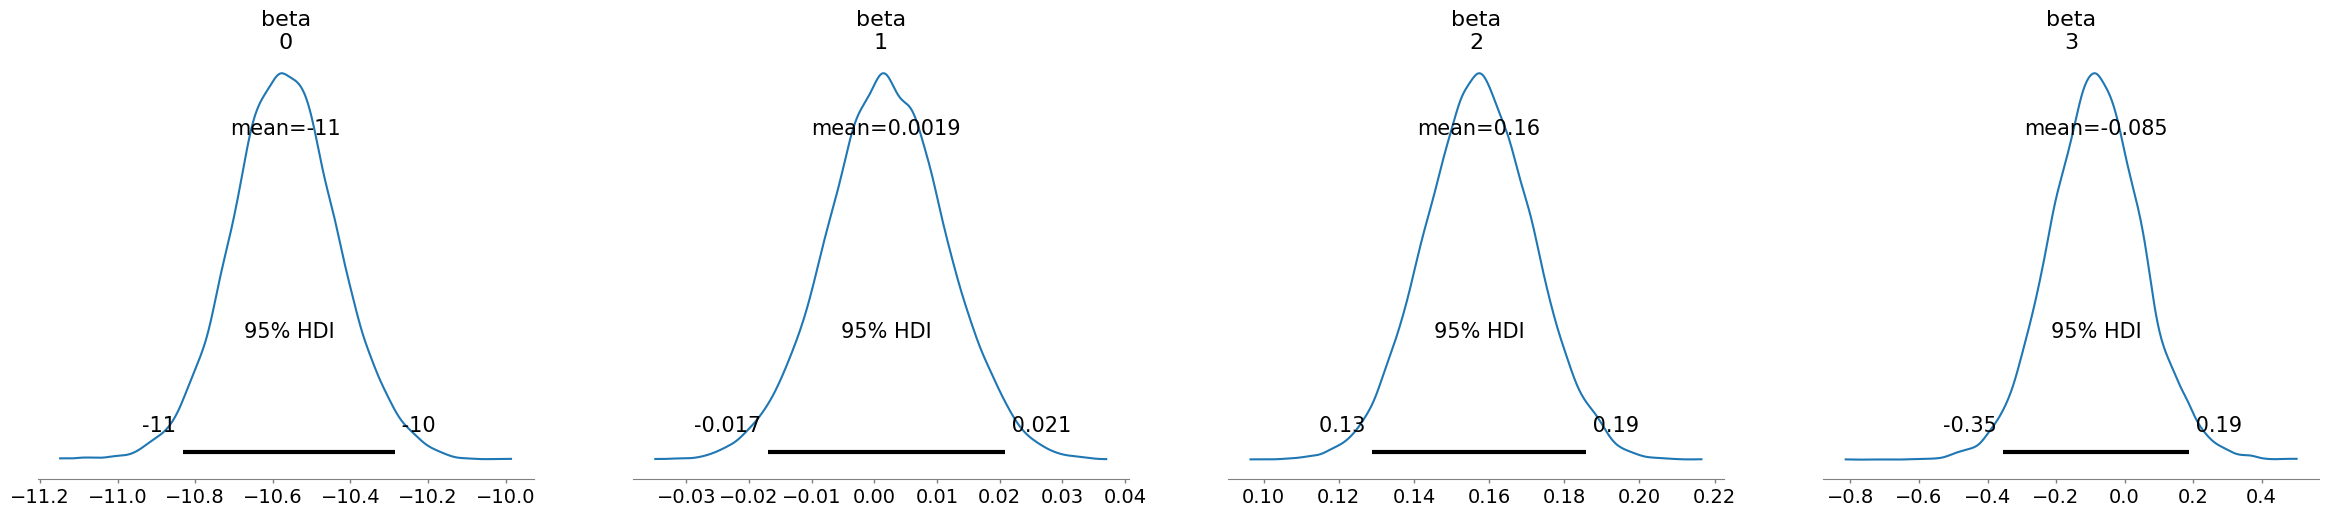

In [27]:
az.plot_posterior(models[model_names[2]]["fit"], var_names=["beta"], hdi_prob=0.95)

In [37]:
def plot_confident_intervals(model_fit, az_data, var_name="beta", eps=0.1):
    
    # Summary with 95% HDI
    sum_beta = az.summary(model_fit, var_names=[var_name], hdi_prob=0.95)
    names = sum_beta.index.to_list()[1:]
    mean  = sum_beta["mean"].values[1:]
    low   = sum_beta["hdi_2.5%"].values[1:]
    high  = sum_beta["hdi_97.5%"].values[1:]
    y = np.arange(len(names))

    # Extract posterior samples
    samples = az_data.posterior[var_name].values
    # Shape: (chains, draws, p)
    samples = samples.reshape(-1, samples.shape[-1])  # (n_samples, p)

    colors = []

    # Assign colors based on posterior mass
    for j in range(samples.shape[1]):
        s = samples[:, j]

        p_neg  = np.mean(s < 0)
        p_pos  = np.mean(s > 0)
        p_zero = np.mean(np.abs(s) < eps)

        if p_neg > 0.5:
            colors.append("red")      # mostly negative effect
        elif p_pos > 0.5:
            colors.append("green")    # mostly positive effect
        elif p_zero > 0.4:
            colors.append("gray")     # mass concentrated near zero
        else:
            colors.append("gray")     # conservative fallback

    # Plot
    plt.figure(figsize=(6, 3))
    for i in range(len(names)):
        plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
        plt.plot(mean[i], y[i], "o", color=colors[i])

    plt.axvline(0, color="black", ls="--", alpha=0.7)
    plt.yticks(y, names)
    plt.xlabel("Beta (log-scale effect)")
    plt.title("Posterior 95% HDI — Beta coefficients")
    plt.tight_layout()
    plt.show()



ab_baseline_simple_poi.stan


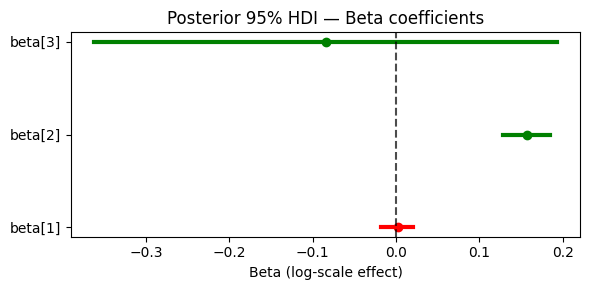

prior_invgamma_54.stan


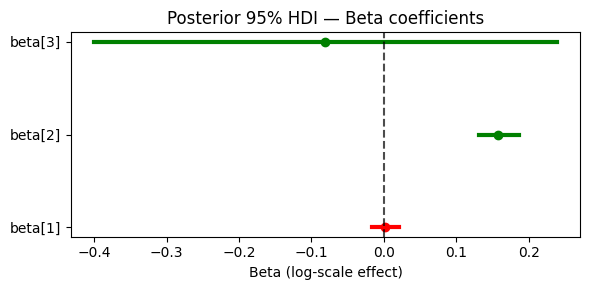

prior_tstudent_31.stan


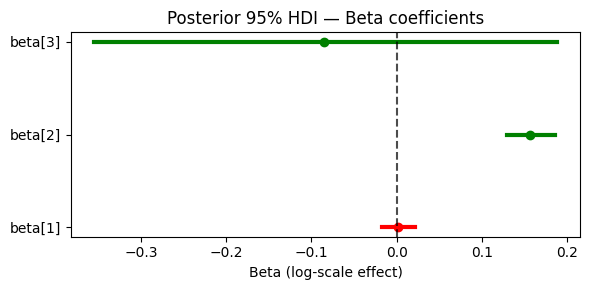

In [38]:
for i in model_names:
    print(i)
    plot_confident_intervals(models[i]["fit"], models[i]["az"],var_name="beta")

### Compare Models 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Libra


=== LOO COMPARISON ===
                             rank     elpd_loo       p_loo  elpd_diff  \
prior_tstudent_31.stan          0 -1608.924106  110.396161   0.000000   
ab_baseline_simple_poi.stan     1 -1609.564542  111.279905   0.640436   
prior_invgamma_54.stan          2 -1609.724913  111.352961   0.800807   

                                   weight         se       dse  warning scale  
prior_tstudent_31.stan       1.000000e+00  83.213283  0.000000     True   log  
ab_baseline_simple_poi.stan  4.163336e-16  83.207095  0.578283     True   log  
prior_invgamma_54.stan       0.000000e+00  83.311015  0.459214     True   log  


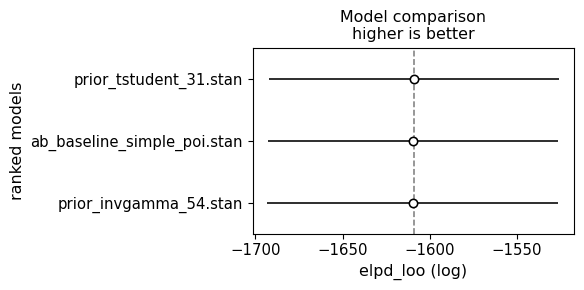

In [30]:
compare_dict = {
}
for key in models:
    compare_dict[key] = models[key]["az"]

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(



=== WAIC COMPARISON ===
                             rank    elpd_waic      p_waic  elpd_diff  \
prior_tstudent_31.stan          0 -1606.445439  107.917494   0.000000   
prior_invgamma_54.stan          1 -1607.095461  108.723509   0.650022   
ab_baseline_simple_poi.stan     2 -1607.385559  109.100922   0.940120   

                                   weight         se       dse  warning scale  
prior_tstudent_31.stan       1.000000e+00  82.963403  0.000000     True   log  
prior_invgamma_54.stan       1.859624e-15  83.034241  0.417800     True   log  
ab_baseline_simple_poi.stan  1.110223e-16  83.059136  0.216513     True   log  


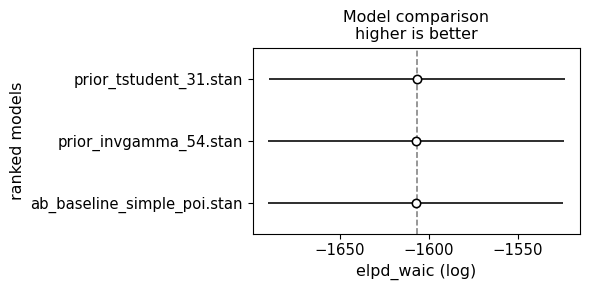

In [31]:
comparison_waic = az.compare(compare_dict, ic="waic")
print("\n=== WAIC COMPARISON ===")
print(comparison_waic)

az.plot_compare(comparison_waic, insample_dev=False)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import pandas as pd

def select_by_hdi(az_data, var_name="beta", credible_mass=0.95, 
                  covariate_names=["Intercept", "IBU", "DMSO", "Temp"]):
    summary = az.summary(az_data, var_names=[var_name], 
                        hdi_prob=credible_mass)
    
    results = []
    for idx, name in enumerate(covariate_names):
        row = summary.iloc[idx]
        hdi_low = row[f"hdi_{(1-credible_mass)/2*100:.1f}%"]
        hdi_high = row[f"hdi_{(1+credible_mass)/2*100:.1f}%"]
        
        crosses_zero = (hdi_low < 0) and (hdi_high > 0)
        
        results.append({
            'variable': name,
            'mean': row['mean'],
            'hdi_low': hdi_low,
            'hdi_high': hdi_high,
            'crosses_zero': crosses_zero,
            'selected': not crosses_zero
        })
    
    return pd.DataFrame(results)

print("=" * 40)
print("HDI-BASED SELECTION (95% credible intervals)")
print("=" * 40)

for model_name in model_names:
    print(f"\n{model_name}:")
    result = select_by_hdi(az_data=models[model_name]["az"], credible_mass=0.95)
    # print(result)
    print(f"Selected: {result[result['selected']]['variable'].tolist()}")

HDI-BASED SELECTION (95% credible intervals)

ab_baseline_simple_poi.stan:
Selected: ['Intercept', 'DMSO']

prior_invgamma_54.stan:
Selected: ['Intercept', 'DMSO']

prior_tstudent_31.stan:
Selected: ['Intercept', 'DMSO']


In [33]:
def posterior_inclusion_probability(az_data, var_name="beta", 
                                   threshold=None,
                                   covariate_names=["Intercept", "IBU", "DMSO", "Temp"], prob=0.5):
    """
    Calculate P(|beta_j| > threshold | data)
    
    If threshold is None, uses practical significance = 0.1 * posterior SD for each variable
    (Rule of thumb: effects smaller than 10% of SD are negligible)
    """
    samples = az_data.posterior[var_name].values
    n_chains, n_draws, p = samples.shape
    
    results = []
    for j in range(p):
        beta_j = samples[:, :, j].flatten()
        
        if threshold is None:
            thresh = 0.1 * np.std(beta_j)
        else:
            thresh = threshold
        
        pip = np.mean(np.abs(beta_j) > thresh)
        
        prob_positive = np.mean(beta_j > thresh)
        prob_negative = np.mean(beta_j < -thresh)
        
        results.append({
            'variable': covariate_names[j],
            'threshold_used': thresh,
            'PIP': pip,
            'P(β > thresh)': prob_positive,
            'P(β < -thresh)': prob_negative,
            'median': np.median(beta_j),
            'sd': np.std(beta_j),
            'selected': pip > prob  
        })
    
    return pd.DataFrame(results)

print("\n" + "=" * 60)
print("POSTERIOR INCLUSION PROBABILITY")
print("=" * 60)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("\n--- Auto threshold (10% of posterior SD) ---")
    result = posterior_inclusion_probability(az_data=models[model_name]["az"], prob=0.8)
    #print(result[['variable', 'threshold_used', 'PIP', 'median', 'sd', 'selected']])
    print(f"Selected (PIP > 0.8): {result[result['selected']]['variable'].tolist()}")
    
    print("\n--- Fixed threshold = 0.1 (practical significance) ---")
    result_fixed = posterior_inclusion_probability(
        models[model_name]["az"],
        threshold=0.1, prob=0.8
    )
    #print(result_fixed[['variable', 'PIP', 'median', 'selected']])
    print(f"Selected: {result_fixed[result_fixed['selected']]['variable'].tolist()}")


POSTERIOR INCLUSION PROBABILITY

ab_baseline_simple_poi.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

prior_invgamma_54.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']

prior_tstudent_31.stan:

--- Auto threshold (10% of posterior SD) ---
Selected (PIP > 0.8): ['Intercept', 'IBU', 'DMSO', 'Temp']

--- Fixed threshold = 0.1 (practical significance) ---
Selected: ['Intercept', 'DMSO']


In [34]:
def cross_model_selection(models_dict, model_names, 
                         covariate_names=["Intercept", "IBU", "DMSO", "Temp"],
                         methods=['hdi', 'pip'], pip_th = None, pip_prob=0.5):
    """
    Variable selected if chosen by majority of models
    """
    selection_matrix = []
    
    for model_name in model_names:
        for method in methods:
            if method == 'hdi':
                result = select_by_hdi(models_dict[model_name]["az"], 
                                      covariate_names=covariate_names)
            if method == 'pip':
                result = posterior_inclusion_probability(
        models_dict[model_name]["az"],
        threshold=pip_th, prob=pip_prob
    )   
            selection_matrix.append(result['selected'].values)
    
    selection_matrix = np.array(selection_matrix)
    
    selection_count = selection_matrix.sum(axis=0)
    
    consensus_df = pd.DataFrame({
        'variable': covariate_names,
        'n_models_selected': selection_count,
        'proportion': selection_count / (len(model_names) * len(methods)),
        'consensus_selected': selection_count >= (len(model_names) * len(methods) / 2)
    })
    
    return consensus_df

working_models = model_names

print("\n" + "=" * 60)
print("CROSS-MODEL CONSENSUS")
print("=" * 60)


CROSS-MODEL CONSENSUS


In [140]:
consensus = cross_model_selection(models, working_models, methods=['hdi', 'pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                 14    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                 14    1.000000                True
3       Temp                  5    0.357143               False

Final selection: ['Intercept', 'DMSO']


In [141]:
consensus = cross_model_selection(models, working_models, methods=['hdi'])
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


In [142]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  7         1.0                True
2       DMSO                  7         1.0                True
3       Temp                  7         1.0                True

Final selection: ['Intercept', 'IBU', 'DMSO', 'Temp']


In [143]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.8, pip_th=0.1)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7         1.0                True
1        IBU                  0         0.0               False
2       DMSO                  7         1.0                True
3       Temp                  0         0.0               False

Final selection: ['Intercept', 'DMSO']


In [144]:
consensus = cross_model_selection(models, working_models, methods=['pip'], pip_prob=0.5, pip_th=0.05)
print(consensus)
print(f"\nFinal selection: {consensus[consensus['consensus_selected']]['variable'].tolist()}")

    variable  n_models_selected  proportion  consensus_selected
0  Intercept                  7    1.000000                True
1        IBU                  0    0.000000               False
2       DMSO                  7    1.000000                True
3       Temp                  5    0.714286                True

Final selection: ['Intercept', 'DMSO', 'Temp']


# comparison_loo 
very expensive -> I need to fit the sample with removing each covariate -> does not make sense. I will include only two covariate to see which one is better (TEMP, DMSO)